In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from matplotlib.dates import YearLocator, DateFormatter

warnings.filterwarnings("ignore")

In [ ]:
# Nome do arquivo principal
igr = 'IGR.csv'

# Códigos de registro da ANS para as empresas
petrobras = 422631
caixa = 312924
cassi = 346659
correios = 419133

# Carregamento do arquivo principal
igr = pd.read_csv(
    "IGR.csv",
    sep=';',
    encoding='utf-8'
    )

# Transformação das colunas e métrica anualizada
igr['COMPETENCIA'] = pd.to_datetime(
    igr['COMPETENCIA'], 
    format='%Y%m'
    )

igr['QTD_RECLAMACOES_12M'] = igr.groupby(
    'REGISTRO_ANS'
    )['QTD_RECLAMACOES'].transform(
        lambda x: x[::-1].rolling(window=12, min_periods=1).sum()[::-1]
        )
    
igr['IGR'] = igr['IGR'].str.replace(',', '.').astype(float)

# Separação dos arquivos para visualização por empresa e seleção de colunas relevantes
colunas_relevantes = ['QTD_RECLAMACOES',
                      'COMPETENCIA',
                      'QTD_RECLAMACOES_12M',
                      'IGR'
                      ]

igr_cassi = igr[igr['REGISTRO_ANS'] == cassi]
igr_correios = igr[igr['REGISTRO_ANS'] == correios]
igr_petrobras = igr[igr['REGISTRO_ANS'] == petrobras]
igr_SC = igr[igr['REGISTRO_ANS'] == caixa]

igr_correios_recl = igr[igr['REGISTRO_ANS'] == correios][colunas_relevantes]
igr_cassi_recl = igr[igr['REGISTRO_ANS'] == cassi][colunas_relevantes]
igr_petrobras_recl = igr[igr['REGISTRO_ANS'] == petrobras][colunas_relevantes]
igr_SC_recl = igr[igr['REGISTRO_ANS'] == caixa][colunas_relevantes]

# Separação por ano
igr_SC_recl_2024 = igr_SC_recl[igr_SC_recl['COMPETENCIA'].dt.year == 2024]
igr_SC_recl_2025 = igr_SC_recl[igr_SC_recl['COMPETENCIA'].dt.year == 2025]
igr_SC_recl_2026 = igr_SC_recl[igr_SC_recl['COMPETENCIA'].dt.year == 2026]

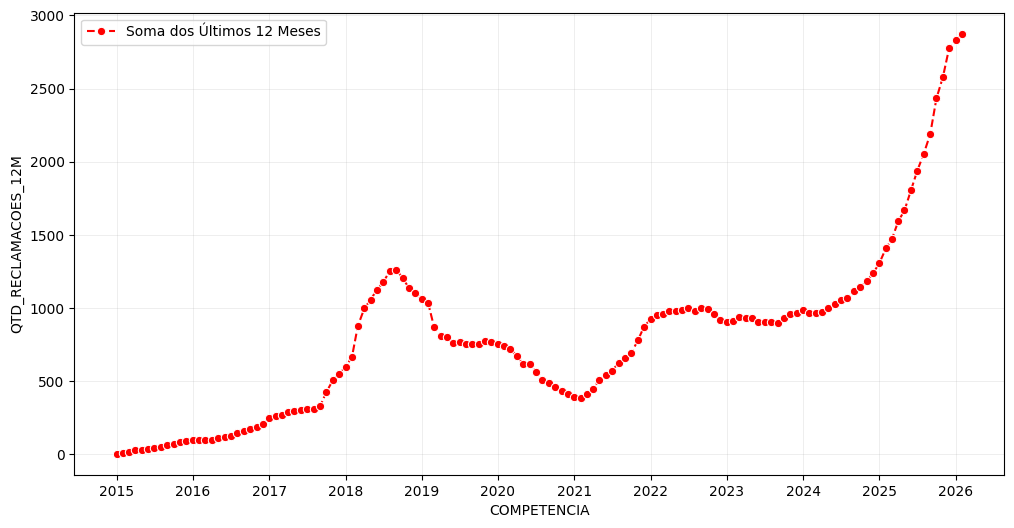

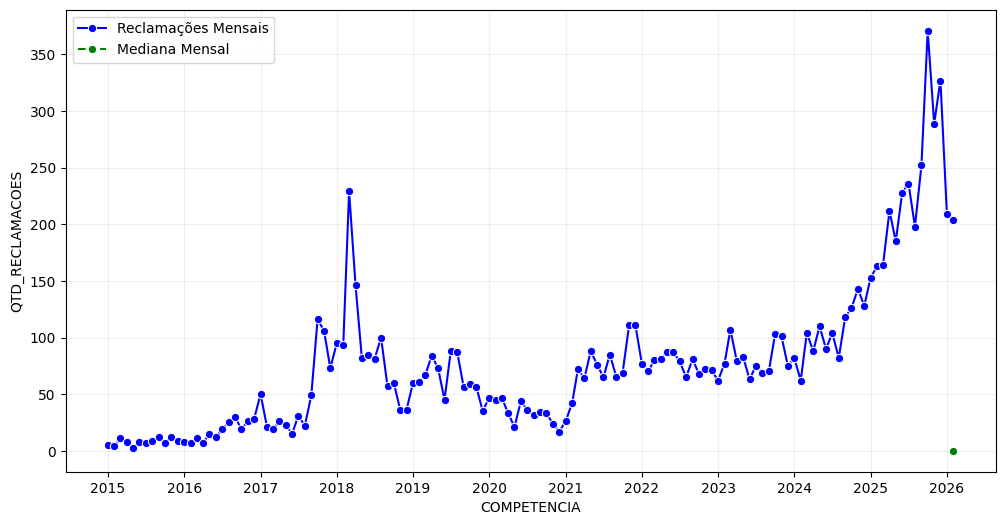

In [ ]:
# Cria a figura e os eixos para o gráfico
a, x = plt.subplots(figsize=(12,6))

# Plota a linha
sns.lineplot(data=igr_SC_recl,
            x='COMPETENCIA',
            y='QTD_RECLAMACOES_12M',
            marker='o',
            color='red',
            label='Soma dos Últimos 12 Meses',
            linestyle='--'
            )

#  Define o período do eixo x para mostrar apenas os anos
x.xaxis.set_major_locator(YearLocator(1))
x.xaxis.set_major_formatter(DateFormatter('%Y'))

# Adiciona linhas de grade
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Adiciona a legenda e mostra a figura/gráfico
plt.legend()
plt.show()

a, x = plt.subplots(figsize=(12,6))

sns.lineplot(data=igr_SC_recl, 
            x='COMPETENCIA',
            y='QTD_RECLAMACOES',
            marker='o',
            color='blue',
            label='Reclamações Mensais')

#sns.lineplot(data=igr_SC_recl, x='COMPETENCIA', y='QTD_RECLAMACOES_12M', marker='o', color='red', label='Soma dos Últimos 12 Meses', linestyle='--')

plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

x.xaxis.set_major_locator(YearLocator(1))
x.xaxis.set_major_formatter(DateFormatter('%Y'))

plt.legend()
plt.show()

In [22]:
igr

,REGISTRO_ANS,RAZAO_SOCIAL,COBERTURA,IGR,QTD_RECLAMACOES,QTD_BENEFICIARIOS,PORTE_OPERADORA,COMPETENCIA,COMPETENCIA_BENEFICIARIO,DT_ATUALIZACAO,QTD_RECLAMACOES_12M
0,515,ALLIANZ SAÚDE S/A,Assistência médica,0.00,0,212,Pequeno,2026-02-01,202601,2026-03-09,7.0
1,582,PORTO SEGURO - SEGURO SAÚDE S/A,Assistência médica,50.16,403,803451,Grande,2026-02-01,202601,2026-03-09,2475.0
2,582,PORTO SEGURO - SEGURO SAÚDE S/A,Exclusivamente odontológica,0.34,4,1170163,Grande,2026-02-01,202601,2026-03-09,2472.0
3,701,UNIMED SEGUROS SAÚDE S/A,Assistência médica,51.98,497,956114,Grande,2026-02-01,202601,2026-03-09,5762.0
4,884,ITAUSEG SAÚDE S.A.,Assistência médica,28.68,2,6973,Pequeno,2026-02-01,202601,2026-03-09,33.0
...,...,...,...,...,...,...,...,...,...,...,...
148548,420905,ESTALEIRO ATLÂNTICO SUL S/A,Assistência médica,0.00,0,5,Pequeno,2015-01-01,201501,NaN,0.0
148549,420972,ORALPLAN PLANOS DE SAUDE ODONTOLÓGICOS - EIRELI,Exclusivamente odontológica,0.00,0,1,Pequeno,2015-01-01,201501,NaN,0.0
148550,421006,ASSOCIAÇÃO SÃO LUIZ SAÚDE,Assistência médica,0.00,0,625,Pequeno,2015-01-01,201501,NaN,0.0
148551,421197,SANTA CASA DE MAUÁ SAÚDE,Assistência médica,0.00,0,80,Pequeno,2015-01-01,201501,NaN,0.0


In [ ]:

# igr_mediana = igr.groupby('COMPETENCIA')['QTD_RECLAMACOES'].median().reset_index()
sns.lineplot(data=igr,
            x='COMPETENCIA',
            y=igr_mediana['QTD_RECLAMACOES'],
            marker='o',
            color='green',
            label='Mediana Mensal',
            linestyle='--')

,COMPETENCIA,QTD_RECLAMACOES
0,2015-01-01,0.0
1,2015-02-01,0.0
2,2015-03-01,0.0
3,2015-04-01,0.0
4,2015-05-01,0.0
...,...,...
129,2025-10-01,1.0
130,2025-11-01,1.0
131,2025-12-01,1.0
132,2026-01-01,1.0


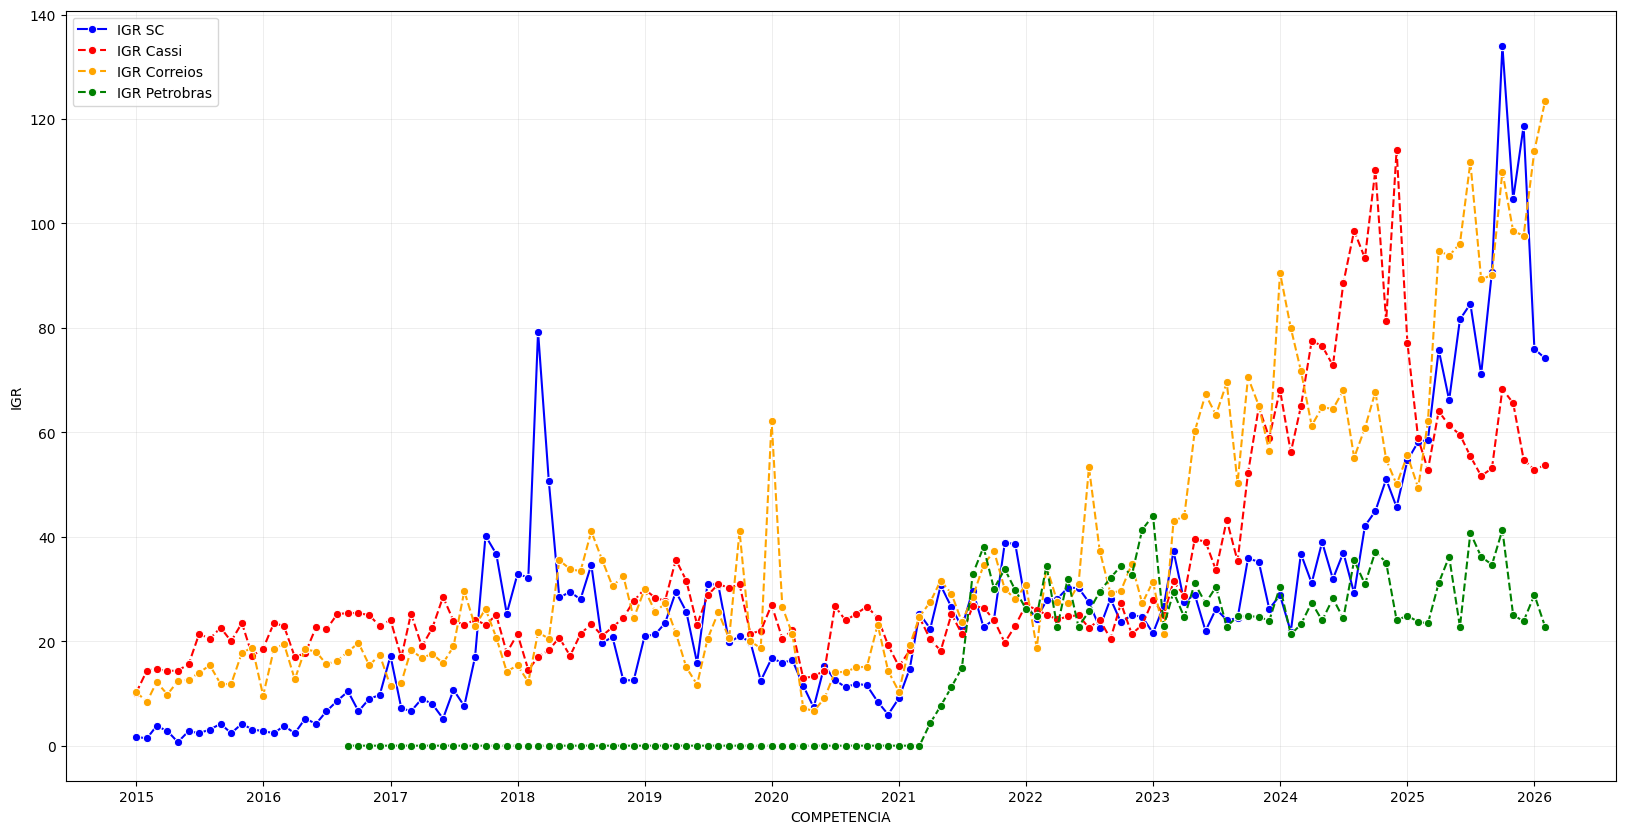

In [12]:
a, x = plt.subplots(figsize=(20,10))
sns.lineplot(data=igr_SC_recl, x='COMPETENCIA', y='IGR', marker='o', color='blue', label='IGR SC')
sns.lineplot(data=igr_cassi_recl, x='COMPETENCIA', y='IGR', marker='o', color='red', label='IGR Cassi', linestyle='--')
sns.lineplot(data=igr_correios_recl, x='COMPETENCIA', y='IGR', marker='o', color='orange', label='IGR Correios', linestyle='--')
sns.lineplot(data=igr_petrobras_recl, x='COMPETENCIA', y='IGR', marker='o', color='green', label='IGR Petrobras', linestyle='--')

plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

from matplotlib.dates import YearLocator, DateFormatter
x.xaxis.set_major_locator(YearLocator(1))
x.xaxis.set_major_formatter(DateFormatter('%Y'))


plt.legend()
plt.show()


In [13]:
igr_SC

,REGISTRO_ANS,RAZAO_SOCIAL,COBERTURA,IGR,QTD_RECLAMACOES,QTD_BENEFICIARIOS,PORTE_OPERADORA,COMPETENCIA,COMPETENCIA_BENEFICIARIO,DT_ATUALIZACAO,QTD_RECLAMACOES_12M
101,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,74.16,204,275073,Grande,2026-02-01,202601,2026-03-09,2875.0
1084,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,75.98,209,275073,Grande,2026-01-01,202601,2026-03-09,2834.0
2067,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,118.71,327,275462,Grande,2025-12-01,202512,2026-03-09,2778.0
3051,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,104.67,289,276110,Grande,2025-11-01,202511,2026-03-09,2579.0
4032,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,134.04,371,276784,Grande,2025-10-01,202510,2026-03-09,2433.0
...,...,...,...,...,...,...,...,...,...,...,...
142062,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,0.70,2,288878,Grande,2015-05-01,201505,NaN,30.0
143385,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,2.80,8,288064,Grande,2015-04-01,201504,NaN,28.0
144712,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,3.80,11,287805,Grande,2015-03-01,201503,NaN,20.0
146041,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,1.40,4,287417,Grande,2015-02-01,201502,NaN,9.0


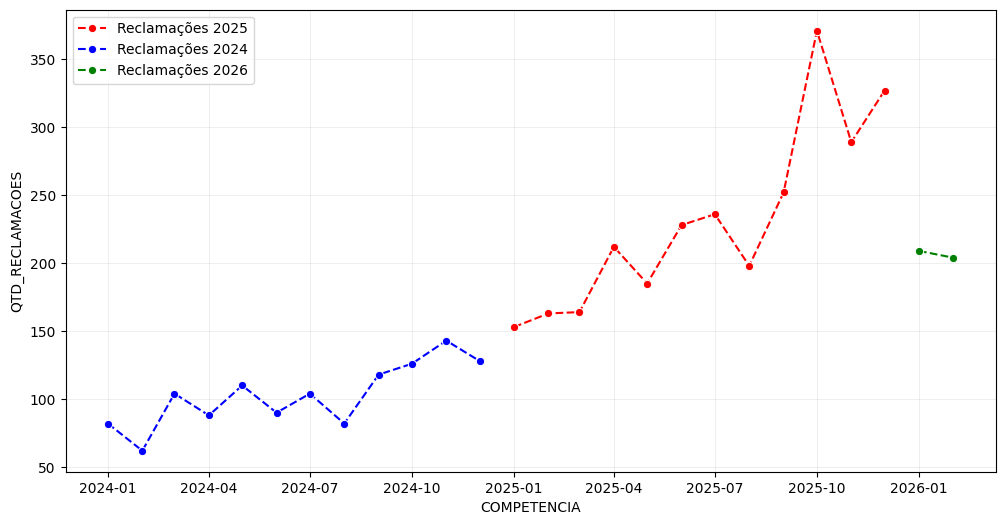

In [16]:
a, x = plt.subplots(figsize=(12,6))
#sns.lineplot(data=igr_SC_recl, x='COMPETENCIA', y='QTD_RECLAMACOES', marker='o', color='blue', label='Reclamações Mensais')
sns.lineplot(data=igr_SC_recl_2025, x='COMPETENCIA', y='QTD_RECLAMACOES', marker='o', color='red', label='Reclamações 2025', linestyle='--')
sns.lineplot(data=igr_SC_recl_2024, x='COMPETENCIA', y='QTD_RECLAMACOES', marker='o', color='blue', label='Reclamações 2024', linestyle='--')
sns.lineplot(data=igr_SC_recl_2026, x='COMPETENCIA', y='QTD_RECLAMACOES', marker='o', color='green', label='Reclamações 2026', linestyle='--')

# Adicionar linhas de grade
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

plt.legend()
plt.show()


In [ ]:
igr.fillna()
igr.mean()
pd.to_numeric()